In [1]:
"""
CHUNK 1: Basic Setup - Install Packages and Import Libraries
"""

# ============================================================================
# STEP 1: Install Required Packages
# ============================================================================
print("Installing required packages...")
!pip install selenium webdriver-manager beautifulsoup4 pandas -q

print("✓ Installation complete!")

# ============================================================================
# STEP 2: Import Libraries
# ============================================================================
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from webdriver_manager.chrome import ChromeDriverManager
from bs4 import BeautifulSoup
import pandas as pd
import time
import re

print("✓ All libraries imported successfully!")
print("\n✅ Setup complete! Ready for next chunk.")

Installing required packages...
✓ Installation complete!
✓ All libraries imported successfully!

✅ Setup complete! Ready for next chunk.


In [2]:
!wget -q https://storage.googleapis.com/chrome-for-testing-public/144.0.7559.109/linux64/chromedriver-linux64.zip
!unzip -o chromedriver-linux64.zip
!mv chromedriver-linux64/chromedriver /usr/bin/chromedriver
!chmod +x /usr/bin/chromedriver


Archive:  chromedriver-linux64.zip
  inflating: chromedriver-linux64/LICENSE.chromedriver  
  inflating: chromedriver-linux64/THIRD_PARTY_NOTICES.chromedriver  
  inflating: chromedriver-linux64/chromedriver  


In [3]:
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options

def setup_driver():
    options = Options()
    options.add_argument("--headless=new")
    options.add_argument("--no-sandbox")
    options.add_argument("--disable-dev-shm-usage")
    options.add_argument("--disable-gpu")

    options.binary_location = "/usr/bin/google-chrome"
    service = Service("/usr/bin/chromedriver")

    return webdriver.Chrome(service=service, options=options)


In [4]:
driver = setup_driver()
driver.get("https://www.google.com")
print(driver.title)
driver.quit()


Google


In [5]:
!chromium --version


/bin/bash: line 1: chromium: command not found


In [6]:
"""
CHUNK 3: Helper Functions for Web Scraping
"""

# ============================================================================
# Function 1: Scroll Page to Load Lazy Content
# ============================================================================
def scroll_page(driver, scroll_pause_time=2, max_scrolls=5):
    """
    Scroll down the page to load all lazy-loaded products

    Args:
        driver: Selenium WebDriver instance
        scroll_pause_time: Seconds to wait between scrolls
        max_scrolls: Maximum number of scrolls

    Returns:
        Number of scrolls performed
    """
    print(f"  Scrolling page to load dynamic content...")

    last_height = driver.execute_script("return document.body.scrollHeight")
    scrolls = 0

    while scrolls < max_scrolls:
        # Scroll to bottom
        driver.execute_script("window.scrollTo(0, document.body.scrollHeight);")
        time.sleep(scroll_pause_time)

        # Calculate new height
        new_height = driver.execute_script("return document.body.scrollHeight")

        # Break if we've reached the end
        if new_height == last_height:
            print(f"    → Reached end after {scrolls + 1} scrolls")
            break

        last_height = new_height
        scrolls += 1
        print(f"    → Scroll {scrolls}/{max_scrolls} completed")

    return scrolls


# ============================================================================
# Function 2: Clean Price Text
# ============================================================================
def clean_price(price_text):
    """
    Extract numeric price from text
    Example: 'Rs. 2,499' -> 2499.0

    Args:
        price_text: String containing price

    Returns:
        Float price or None
    """
    if not price_text or price_text == "N/A":
        return None

    # Remove currency symbols and commas, keep only digits
    cleaned = re.sub(r'[^\d]', '', price_text)

    try:
        return float(cleaned) if cleaned else None
    except:
        return None


# ============================================================================
# Function 3: Clean Rating
# ============================================================================
def clean_rating(rating_text):
    """
    Extract numeric rating from text
    Example: '4.5' -> 4.5

    Args:
        rating_text: String containing rating

    Returns:
        Float rating or None
    """
    if not rating_text or rating_text == "N/A":
        return None

    try:
        # Find first number (with optional decimal)
        match = re.search(r'\d+\.?\d*', rating_text)
        if match:
            return float(match.group())
    except:
        pass

    return None


# ============================================================================
# Function 4: Extract Number from Text
# ============================================================================
def extract_number(text):
    """
    Extract number from text (for sold units, reviews count, etc.)
    Example: '1.5k sold' -> 1500

    Args:
        text: String containing number

    Returns:
        Integer or None
    """
    if not text:
        return None

    try:
        # Handle 'k' notation (thousands)
        if 'k' in text.lower():
            match = re.search(r'(\d+\.?\d*)\s*k', text.lower())
            if match:
                return int(float(match.group(1)) * 1000)

        # Extract regular number
        match = re.search(r'\d+', text)
        if match:
            return int(match.group())
    except:
        pass

    return None


# ============================================================================
# Function 5: Safe Text Extraction
# ============================================================================
def safe_get_text(element, default="N/A"):
    """
    Safely extract text from BeautifulSoup element

    Args:
        element: BeautifulSoup element
        default: Default value if element is None

    Returns:
        Extracted text or default value
    """
    if element:
        text = element.get_text(strip=True)
        return text if text else default
    return default


# ============================================================================
# Test the Helper Functions
# ============================================================================
print("Testing helper functions...\n")

# Test clean_price
test_prices = ["Rs. 2,499", "Rs 1,999", "3500", "N/A"]
print("Testing clean_price():")
for price in test_prices:
    print(f"  '{price}' -> {clean_price(price)}")

# Test clean_rating
test_ratings = ["4.5", "3.8 (120)", "N/A", "5"]
print("\nTesting clean_rating():")
for rating in test_ratings:
    print(f"  '{rating}' -> {clean_rating(rating)}")

# Test extract_number
test_numbers = ["1.5k sold", "250 sold", "12k", "N/A"]
print("\nTesting extract_number():")
for num in test_numbers:
    print(f"  '{num}' -> {extract_number(num)}")

print("\n✅ All helper functions created successfully!")

Testing helper functions...

Testing clean_price():
  'Rs. 2,499' -> 2499.0
  'Rs 1,999' -> 1999.0
  '3500' -> 3500.0
  'N/A' -> None

Testing clean_rating():
  '4.5' -> 4.5
  '3.8 (120)' -> 3.8
  'N/A' -> None
  '5' -> 5.0

Testing extract_number():
  '1.5k sold' -> 1500
  '250 sold' -> 250
  '12k' -> 12000
  'N/A' -> None

✅ All helper functions created successfully!


In [7]:
"""
CHUNK 4.1: Inspect HTML Structure to Find Correct Selectors
"""

print("Inspecting Daraz HTML structure...")
print("="*60)

# Initialize driver
driver = setup_driver()
print(f"here is the {driver}")

print("i am printing end end end before laoding the page")

# Load the page
test_url = "https://www.daraz.pk/catalog/?q=track+suits&page=1"
driver.get(test_url)
time.sleep(3)

# Get page source
page_source = driver.page_source
soup = BeautifulSoup(page_source, 'html.parser')

# Find first product
products = soup.find_all('div', {'data-qa-locator': 'product-item'})
print(f"Found {len(products)} products\n")

if products:
    first_product = products[0]

    print("="*60)
    print("FIRST PRODUCT HTML STRUCTURE:")
    print("="*60)
    print(first_product.prettify()[:2000])  # Print first 2000 characters
    print("\n... (truncated)")

    print("\n" + "="*60)
    print("ANALYZING ELEMENTS:")
    print("="*60)

    # Find all spans with text
    all_spans = first_product.find_all('span')
    print(f"\nFound {len(all_spans)} <span> elements:")
    for idx, span in enumerate(all_spans[:15]):  # First 15 spans
        text = span.get_text(strip=True)
        classes = span.get('class', [])
        if text:
            print(f"  {idx+1}. Text: '{text}' | Classes: {classes}")

    # Find all divs with text
    all_divs = first_product.find_all('div', recursive=False)
    print(f"\n\nFound {len(all_divs)} direct <div> children:")
    for idx, div in enumerate(all_divs[:10]):
        text = div.get_text(strip=True)[:100]  # First 100 chars
        classes = div.get('class', [])
        print(f"  {idx+1}. Text: '{text}...' | Classes: {classes}")

driver.quit()
print("\n✅ Inspection complete!")

Inspecting Daraz HTML structure...
here is the <selenium.webdriver.chrome.webdriver.WebDriver (session="8dde27f7fd180867c84c632089f18b57")>
i am printing end end end before laoding the page
Found 40 products

FIRST PRODUCT HTML STRUCTURE:
<div class="Bm3ON" data-aplus-ae="x1_53e1e1a4" data-aplus-clk="x1_53e1e1a4" data-item-id="915780974" data-listno="0" data-qa-locator="product-item" data-sku-simple="915780974_PK-3964306610" data-spm-anchor-id="a2a0e.searchlist.list.i0.59021596Z3It1s" data-tracking="product-card" data-utlogmap='{"listno":0,"pageIndex":1,"pvid":"345539908c635a015321b0f6d35d0fac","query":"track suits","style":"wf","x_item_ids":"915780974","x_object_id":"915780974","x_object_type":"item"}'>
 <div class="Ms6aG">
  <div class="qmXQo">
   <div class="ICdUp">
    <div class="_95X4G">
     <a href="//www.daraz.pk/products/-i915780974.html">
      <div class="picture-wrapper jBwCF">
       <img alt="Mens track suit best quility ma ap ka liya" src="https://img.drz.lazcdn.com/g/k

In [8]:
"""
CHUNK 4: Scrape Listing Page (UPDATED with Correct Selectors)
"""

def scrape_listing_page(driver, page_url):
    """
    Scrape one listing page and extract product information

    Args:
        driver: Selenium WebDriver instance
        page_url: URL of the listing page to scrape

    Returns:
        List of dictionaries containing product data
    """
    print(f"\nScraping: {page_url}")

    # Navigate to the page
    driver.get(page_url)
    time.sleep(3)  # Wait for initial load

    # Scroll to load all products
    scroll_page(driver, scroll_pause_time=2, max_scrolls=3)

    # Get page source and parse with BeautifulSoup
    page_source = driver.page_source
    soup = BeautifulSoup(page_source, 'html.parser')

    # Find all product items - Daraz uses data-qa-locator="product-item"
    products = soup.find_all('div', {'data-qa-locator': 'product-item'})

    print(f"  Found {len(products)} products on this page")

    # Store data for all products
    products_data = []

    # Loop through each product
    for idx, product in enumerate(products, 1):
        try:
            # Extract product name - in div with class "RfADt"
            name_elem = product.find('div', class_='RfADt')
            if name_elem:
                name_link = name_elem.find('a')
                product_name = safe_get_text(name_link)
            else:
                product_name = "N/A"

            # Extract product URL
            link_elem = product.find('a', href=True)
            product_url = link_elem['href'] if link_elem else "N/A"
            if product_url != "N/A" and not product_url.startswith('http'):
                product_url = "https:" + product_url

            # Extract current price - span with class "ooOxS"
            price_elem = product.find('span', class_='ooOxS')
            current_price_text = safe_get_text(price_elem)
            current_price = clean_price(current_price_text)

            # Extract original price (crossed out) - usually in <del> tag or specific class
            original_price_elem = product.find('del')
            if not original_price_elem:
                # Try alternate selectors
                original_price_elem = product.find('span', class_=re.compile('origin|old'))
            original_price_text = safe_get_text(original_price_elem)
            original_price = clean_price(original_price_text)

            # Calculate discount if both prices exist
            discount = None
            if current_price and original_price:
                discount = round(((original_price - current_price) / original_price) * 100, 1)
            else:
                # Try to find discount badge
                discount_elem = product.find('span', class_=re.compile('discount'))
                if discount_elem:
                    discount = extract_number(safe_get_text(discount_elem))

            # Extract rating - count filled stars (class "Dy1nx")
            rating = None
            rating_div = product.find('div', class_='mdmmT')
            if rating_div:
                filled_stars = rating_div.find_all('i', class_='Dy1nx')
                if filled_stars:
                    rating = float(len(filled_stars))

            # Extract reviews count - span with class "qzqFw"
            reviews_elem = product.find('span', class_='qzqFw')
            reviews_text = safe_get_text(reviews_elem)
            reviews_count = extract_number(reviews_text)

            # Extract sold units - span with class "_1cEkb"
            sold_elem = product.find('span', class_='_1cEkb')
            sold_text = safe_get_text(sold_elem)
            sold_units = extract_number(sold_text)

            # Extract location - span with class "oa6ri"
            location_elem = product.find('span', class_='oa6ri')
            location = safe_get_text(location_elem)

            # Create product dictionary
            product_data = {
                'Product_Name': product_name,
                'Current_Price': current_price,
                'Original_Price': original_price,
                'Discount_Percentage': discount,
                'Rating': rating,
                'Reviews_Count': reviews_count,
                'Sold_Units': sold_units,
                'Location': location,
                'Product_URL': product_url
            }

            products_data.append(product_data)

            # Print progress every 10 products
            if idx % 10 == 0:
                print(f"    → Processed {idx}/{len(products)} products...")

        except Exception as e:
            print(f"    ⚠ Error processing product {idx}: {str(e)}")
            continue

    print(f"  ✓ Successfully scraped {len(products_data)} products")
    return products_data


# ============================================================================
# Test the UPDATED Listing Scraper
# ============================================================================
print("Testing UPDATED listing page scraper...")
print("="*60)

# Initialize driver
driver = setup_driver()

# Test URL - First page of track suits
test_url = "https://www.daraz.pk/catalog/?q=track+suits&page=1"

# Scrape the page
products_data = scrape_listing_page(driver, test_url)

# Close driver
driver.quit()

# Convert to DataFrame to see results
df = pd.DataFrame(products_data)

print("\n" + "="*60)
print("SCRAPING RESULTS")
print("="*60)
print(f"\nTotal products scraped: {len(df)}")
print("\nFirst 5 products:")
print(df.head())

print("\nData Summary:")
print(f"  Products with prices: {df['Current_Price'].notna().sum()}")
print(f"  Products with ratings: {df['Rating'].notna().sum()}")
print(f"  Products with sold units: {df['Sold_Units'].notna().sum()}")
print(f"  Products with location: {df['Location'].notna().sum()}")

print("\n✅ Listing page scraper updated and tested!")

Testing UPDATED listing page scraper...

Scraping: https://www.daraz.pk/catalog/?q=track+suits&page=1
  Scrolling page to load dynamic content...
    → Reached end after 1 scrolls
  Found 40 products on this page
    → Processed 10/40 products...
    → Processed 20/40 products...
    → Processed 30/40 products...
    → Processed 40/40 products...
  ✓ Successfully scraped 40 products

SCRAPING RESULTS

Total products scraped: 40

First 5 products:
                                        Product_Name  Current_Price  \
0         Mens track suit best quility ma ap ka liya          899.0   
1  AmazeWear - Black Track Suit With Stylish Prin...         1299.0   
2  Poleyster Printed Track Suit Summer Winter Tra...          999.0   
3         Premium 67 Brown Printed Hoodie Track suit         1499.0   
4  Men's track suit printed Nasa best quility ap ...          899.0   

  Original_Price Discount_Percentage  Rating  Reviews_Count  Sold_Units  \
0           None                None     NaN   

In [9]:
"""
CHUNK 5: Scrape ALL Pages of Track Suits
"""

def scrape_all_pages(base_url, max_pages=None):
    """
    Scrape all pages of track suits from Daraz

    Args:
        base_url: Base URL without page number
        max_pages: Maximum pages to scrape (None = all pages)

    Returns:
        DataFrame with all products
    """
    print("="*60)
    print("STARTING MULTI-PAGE SCRAPING")
    print("="*60)

    # Initialize driver
    driver = setup_driver()

    all_products = []
    page_num = 1

    try:
        while True:
            # Check if we've reached max_pages
            if max_pages and page_num > max_pages:
                print(f"\nReached maximum page limit ({max_pages})")
                break

            # Construct URL for current page
            page_url = f"{base_url}&page={page_num}"

            # Scrape the page
            products_data = scrape_listing_page(driver, page_url)

            # If no products found, we've reached the end
            if not products_data or len(products_data) == 0:
                print(f"\nNo products found on page {page_num}. Reached the end.")
                break

            # Add products to our collection
            all_products.extend(products_data)

            print(f"  Total products collected so far: {len(all_products)}")

            # Move to next page
            page_num += 1

            # Small delay to be respectful to the server
            time.sleep(2)

    except KeyboardInterrupt:
        print("\n\n⚠ Scraping interrupted by user")

    except Exception as e:
        print(f"\n⚠ Error occurred: {str(e)}")

    finally:
        # Always close the driver
        driver.quit()
        print("\nDriver closed.")

    # Convert to DataFrame
    df = pd.DataFrame(all_products)

    print("\n" + "="*60)
    print("SCRAPING COMPLETE!")
    print("="*60)
    print(f"Total products scraped: {len(df)}")
    print(f"Total pages scraped: {page_num - 1}")

    return df


# ============================================================================
# RUN THE SCRAPER (Start with just 3 pages for testing)
# ============================================================================

print("Starting scraper for track suits...")
print("Testing with first 3 pages only...\n")

base_url = "https://www.daraz.pk/catalog/?q=track+suits"

# Scrape first 3 pages as a test
df_tracksuit = scrape_all_pages(base_url, max_pages=3)

# Display results
print("\n" + "="*60)
print("RESULTS PREVIEW")
print("="*60)
print(f"\nDataset shape: {df_tracksuit.shape}")
print("\nFirst 10 products:")
print(df_tracksuit.head(10))

print("\nData completeness:")
for col in df_tracksuit.columns:
    non_null = df_tracksuit[col].notna().sum()
    percentage = (non_null / len(df_tracksuit)) * 100
    print(f"  {col}: {non_null}/{len(df_tracksuit)} ({percentage:.1f}%)")

print("\n✅ Test run complete!")
print("\nTo scrape ALL pages, run:")
print("df_tracksuit_full = scrape_all_pages(base_url, max_pages=None)")

Starting scraper for track suits...
Testing with first 3 pages only...

STARTING MULTI-PAGE SCRAPING

Scraping: https://www.daraz.pk/catalog/?q=track+suits&page=1
  Scrolling page to load dynamic content...
    → Reached end after 1 scrolls
  Found 40 products on this page
    → Processed 10/40 products...
    → Processed 20/40 products...
    → Processed 30/40 products...
    → Processed 40/40 products...
  ✓ Successfully scraped 40 products
  Total products collected so far: 40

Scraping: https://www.daraz.pk/catalog/?q=track+suits&page=2
  Scrolling page to load dynamic content...
    → Reached end after 1 scrolls
  Found 40 products on this page
    → Processed 10/40 products...
    → Processed 20/40 products...
    → Processed 30/40 products...
    → Processed 40/40 products...
  ✓ Successfully scraped 40 products
  Total products collected so far: 80

Scraping: https://www.daraz.pk/catalog/?q=track+suits&page=3
  Scrolling page to load dynamic content...
    → Reached end after 1

In [ ]:
"""
SCRAPE ALL PAGES - FULL TRACK SUITS DATASET
"""

print("="*60)
print("SCRAPING ALL PAGES OF TRACK SUITS")
print("="*60)
print("\nThis may take 5-15 minutes depending on total pages...")
print("You'll see progress for each page.\n")

# Base URL
base_url = "https://www.daraz.pk/catalog/?q=track+suits"

# Scrape ALL pages (max_pages=None means no limit)
df_tracksuit_full = scrape_all_pages(base_url, max_pages=None)

# Display final statistics
print("\n" + "="*60)
print("FINAL DATASET STATISTICS")
print("="*60)

print(f"\n Total Products: {len(df_tracksuit_full)}")
print(f" Total Columns: {len(df_tracksuit_full.columns)}")

print("\n Data Completeness:")
for col in df_tracksuit_full.columns:
    non_null = df_tracksuit_full[col].notna().sum()
    percentage = (non_null / len(df_tracksuit_full)) * 100
    print(f"  {col}: {non_null}/{len(df_tracksuit_full)} ({percentage:.1f}%)")

print("\n Price Statistics:")
print(f"  Min Price: Rs. {df_tracksuit_full['Current_Price'].min():.0f}")
print(f"  Max Price: Rs. {df_tracksuit_full['Current_Price'].max():.0f}")
print(f"  Average Price: Rs. {df_tracksuit_full['Current_Price'].mean():.0f}")
print(f"  Median Price: Rs. {df_tracksuit_full['Current_Price'].median():.0f}")

print("\n Rating Statistics:")
ratings = df_tracksuit_full['Rating'].dropna()
if len(ratings) > 0:
    print(f"  Average Rating: {ratings.mean():.2f}")
    print(f"  Products with 5 stars: {(ratings == 5.0).sum()}")
    print(f"  Products with 4+ stars: {(ratings >= 4.0).sum()}")

print("\n Location Distribution:")
location_counts = df_tracksuit_full['Location'].value_counts()
for loc, count in location_counts.head(5).items():
    print(f"  {loc}: {count} products")

# Save to CSV
csv_filename = 'tracksuit_listing_data_full.csv'
df_tracksuit_full.to_csv(csv_filename, index=False)

print("\n" + "="*60)
print(f" DATA SAVED TO: {csv_filename}")
print("="*60)

print("\n You can download this file from Colab:")
print("   Files → tracksuit_listing_data_full.csv → Right-click → Download")

print("\n Next Step: Phase 2 - Product Detail Scraping")
print("   (Get specifications, seller info, warranty, etc.)")


SCRAPING ALL PAGES OF TRACK SUITS

This may take 5-15 minutes depending on total pages...
You'll see progress for each page.

STARTING MULTI-PAGE SCRAPING
Setting up Chrome WebDriver...
✓ Chrome WebDriver initialized successfully

Scraping: https://www.daraz.pk/catalog/?q=track+suits&page=1
  Scrolling page to load dynamic content...
    → Reached end after 1 scrolls
  Found 40 products on this page
    → Processed 10/40 products...
    → Processed 20/40 products...
    → Processed 30/40 products...
    → Processed 40/40 products...
  ✓ Successfully scraped 40 products
  Total products collected so far: 40

Scraping: https://www.daraz.pk/catalog/?q=track+suits&page=2
  Scrolling page to load dynamic content...
    → Reached end after 1 scrolls
  Found 40 products on this page
    → Processed 10/40 products...
    → Processed 20/40 products...
    → Processed 30/40 products...
    → Processed 40/40 products...
  ✓ Successfully scraped 40 products
  Total products collected so far: 80

S

In [ ]:
# Inspect one product page to find selectors

driver = setup_driver()

# Use first product URL from our data
test_url = "https://www.daraz.pk/products/-i434383902.html"

driver.get(test_url)
time.sleep(3)

soup = BeautifulSoup(driver.page_source, 'html.parser')

# Find specifications section
specs = soup.find('div', class_=re.compile('specification|spec|product-detail'))
if specs:
    print("Specifications section found:")
    print(specs.prettify()[:1500])

# Find seller info
seller = soup.find('div', class_=re.compile('seller|shop'))
if seller:
    print("\n\nSeller section found:")
    print(seller.prettify()[:1000])

# Find warranty/return
warranty = soup.find_all(text=re.compile('warranty|return|delivery', re.IGNORECASE))
print("\n\nWarranty/Return/Delivery mentions:")
for w in warranty[:5]:
    print(f"  - {w.strip()}")

driver.quit()

Setting up Chrome WebDriver...
✓ Chrome WebDriver initialized successfully
Specifications section found:
<div class="pdp-block pdp-block__product-detail" id="block-bZ14Rl_zXWP">
 <div class="pdp-block module" id="module_flash_sale">
 </div>
 <div class="pdp-block module" id="module_crazy_deal">
 </div>
 <div class="pdp-block module" id="module_redmart_top_promo_banner">
 </div>
 <div class="pdp-block module" id="module_product_title_1">
  <div class="pdp-product-title">
   <div class="pdp-mod-product-badge-wrapper">
    <h1 class="pdp-mod-product-badge-title">
     SIDE FACE LION Printed Tracksuit For Men and Boys - Soft and Comfortable Fabric Sweat Shirt and Trouser winter Track suit
    </h1>
   </div>
  </div>
 </div>
 <div class="pdp-block module" id="module_pre-order-tag">
 </div>
 <div class="pdp-block pdp-block__rating-questions-summary" id="block-nLaRf3Tb7sI">
  <div class="pdp-block pdp-block__rating-questions" id="block-vMw4EgV_F2C">
   <div class="pdp-block module" id="modul

/tmp/ipython-input-657883245.py:26: DeprecationWarning: The 'text' argument to find()-type methods is deprecated. Use 'string' instead.
  warranty = soup.find_all(text=re.compile('warranty|return|delivery', re.IGNORECASE))


In [ ]:
"""
Phase 2.2: Product Detail Scraper
"""
#Add imports at top
import pandas as pd
from bs4 import BeautifulSoup
import time
import re

def scrape_product_details(driver, product_url):
    """
    Scrape detailed information from individual product page

    Args:
        driver: Selenium WebDriver
        product_url: URL of product page

    Returns:
        Dictionary with product details
    """
    print(f"  Scraping details from: {product_url[:50]}...")

    try:
        driver.get(product_url)
        time.sleep(2)

        soup = BeautifulSoup(driver.page_source, 'html.parser')

        details = {}

        # Get specifications
        spec_section = soup.find('div', class_=re.compile('pdp-product-detail'))
        if spec_section:
            # Find all key-value pairs in specifications
            spec_items = spec_section.find_all('li', class_=re.compile('key-li'))
            for item in spec_items:
                key = item.find('span', class_=re.compile('key-title'))
                value = item.find('div', class_=re.compile('html-content'))
                if key and value:
                    key_text = key.get_text(strip=True)
                    value_text = value.get_text(strip=True)
                    details[key_text] = value_text

        # Get product description
        desc_section = soup.find('div', class_=re.compile('pdp-product-desc'))
        if desc_section:
            details['Description'] = desc_section.get_text(strip=True)[:500]  # First 500 chars

        # Get warranty info
        warranty = soup.find(text=re.compile('warranty', re.IGNORECASE))
        if warranty:
            warranty_container = warranty.find_parent('div')
            if warranty_container:
                details['Warranty'] = warranty_container.get_text(strip=True)

        # Get return policy
        return_policy = soup.find(text=re.compile('return|days', re.IGNORECASE))
        if return_policy:
            return_container = return_policy.find_parent('div')
            if return_container:
                details['Return_Policy'] = return_container.get_text(strip=True)

        # Get delivery info
        delivery = soup.find('div', class_=re.compile('delivery'))
        if delivery:
            details['Delivery_Info'] = delivery.get_text(strip=True)

        # Get seller info
        seller_section = soup.find('div', class_=re.compile('seller'))
        if seller_section:
            seller_name = seller_section.find('a', class_=re.compile('seller'))
            if seller_name:
                details['Seller_Name'] = seller_name.get_text(strip=True)

            seller_rating = seller_section.find('span', class_=re.compile('rating'))
            if seller_rating:
                details['Seller_Rating'] = seller_rating.get_text(strip=True)

        return details

    except Exception as e:
        print(f"    Error scraping {product_url}: {str(e)}")
        return {}




driver = setup_driver()

# Load the existing data
#Test on first 3 products
print("Testing product detail scraper...")
print("="*60)

driver = setup_driver()

# Use the already loaded df_test
print(f"Using {len(df_test)} products from CSV\n")

# Test on first 3 products
for i in range(3):
    url = df_test.iloc[i]['Product_URL']
    details = scrape_product_details(driver, url)

    print(f"\nProduct {i+1}: {df_test.iloc[i]['Product_Name'][:50]}")
    print(f"URL: {url}")
    for key, value in details.items():
        print(f"  {key}: {str(value)[:100]}")
    print("-"*60)

driver.quit()
print("\n✅ Test complete!")

Testing product detail scraper...
Using 3675 products from CSV

  Scraping details from: https://www.daraz.pk/products/-i434383902.html...


/tmp/ipython-input-84480012.py:50: DeprecationWarning: The 'text' argument to find()-type methods is deprecated. Use 'string' instead.
  warranty = soup.find(text=re.compile('warranty', re.IGNORECASE))
/tmp/ipython-input-84480012.py:57: DeprecationWarning: The 'text' argument to find()-type methods is deprecated. Use 'string' instead.
  return_policy = soup.find(text=re.compile('return|days', re.IGNORECASE))



Product 1: SIDE FACE LION Printed Tracksuit For Men and Boys 
URL: https://www.daraz.pk/products/-i434383902.html
  Warranty: Return & Warranty
  Delivery_Info: Delivery OptionsSindh, Karachi - Gulshan-e-Iqbal, Block 15CHANGEStandard DeliveryGuaranteed by 26-30
  Seller_Name: ZM Garments
------------------------------------------------------------
  Scraping details from: https://www.daraz.pk/products/-i584911127.html...

Product 2: Black the boys Print Winter Track Suit Hoodie and 
URL: https://www.daraz.pk/products/-i584911127.html
  Delivery_Info: 
------------------------------------------------------------
  Scraping details from: https://www.daraz.pk/products/eak-2-i925353401.htm...

Product 3: Black & white EAK Design Men's Winter Collection 2
URL: https://www.daraz.pk/products/eak-2-i925353401.html
  Warranty: Return & Warranty
  Delivery_Info: Delivery OptionsSindh, Karachi - Gulshan-e-Iqbal, Block 15CHANGEStandard DeliveryGuaranteed by 24-26
  Seller_Name: Fashion Garments H

In [ ]:
#above i was unable to find the csv file so i am checking the file heer
import os
print("Files in current directory:")
for file in os.listdir():
    if file.endswith('.csv'):
        print(f"  - {file}")

Files in current directory:


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import pandas as pd

df_test = pd.read_csv('/content/drive/MyDrive/tracksuit_listing_data_full.csv')
print(f" Loaded {len(df_test)} products")
print(df_test.head())

 Loaded 3675 products
                                        Product_Name  Current_Price  \
0  SIDE FACE LION Printed Tracksuit For Men and B...          999.0   
1  Black the boys Print Winter Track Suit Hoodie ...         1299.0   
2  Black & white EAK Design Men's Winter Collecti...         1189.0   
3  Christiano Ronaldo  CR7 printed kangroo hoodie...         1299.0   
4    NASA Print Winter Track Suit Hoodie and Trouser         1299.0   

   Original_Price  Discount_Percentage  Rating  Reviews_Count  Sold_Units  \
0             NaN                  NaN     4.0           14.0        80.0   
1             NaN                  NaN     4.0          218.0      1500.0   
2             NaN                  NaN     5.0            6.0        30.0   
3             NaN                  NaN     4.0           76.0       411.0   
4             NaN                  NaN     4.0           10.0        37.0   

  Location                                        Product_URL  
0   Punjab     https://w

In [ ]:
"""
Final: Scrape ALL Product Details and Merge with Listing Data
"""

def scrape_all_product_details(df, max_products=None):
    """
    Scrape details for all products in DataFrame

    Args:
        df: DataFrame with Product_URL column
        max_products: Limit number of products (None = all)

    Returns:
        DataFrame with added detail columns
    """
    driver = setup_driver()

    total = len(df) if not max_products else min(max_products, len(df))
    print(f"Scraping details for {total} products...")
    print("="*60)

    all_details = []

    for i in range(total):
        url = df.iloc[i]['Product_URL']
        print(f"\n[{i+1}/{total}] {df.iloc[i]['Product_Name'][:40]}...")

        details = scrape_product_details(driver, url)
        all_details.append(details)

        # Progress every 50 products
        if (i + 1) % 50 == 0:
            print(f"\n✓ Completed {i+1}/{total} products")

        # Small delay
        time.sleep(1)

    driver.quit()

    # Convert to DataFrame
    details_df = pd.DataFrame(all_details)

    # Merge with original data
    result_df = pd.concat([df.iloc[:total].reset_index(drop=True), details_df], axis=1)

    return result_df


# OPTION 1: Test on 10 products first
print("OPTION 1: Testing on 10 products")
df_sample = scrape_all_product_details(df_test, max_products=10)

print("\n" + "="*60)
print("SAMPLE RESULTS")
print("="*60)
print(f"\nColumns: {df_sample.columns.tolist()}")
print(f"\nShape: {df_sample.shape}")
print("\nFirst product details:")
print(df_sample.iloc[0])

# Save sample
df_sample.to_csv('/content/drive/MyDrive/tracksuit_SAMPLE_complete.csv', index=False)
print("\n✅ Sample saved: tracksuit_SAMPLE_complete.csv")

print("\n" + "="*60)
print("TO SCRAPE ALL 3675 PRODUCTS:")
print("="*60)
print("Run this:")
print("df_complete = scrape_all_product_details(df_test)")
print("df_complete.to_csv('/content/drive/MyDrive/tracksuit_COMPLETE.csv', index=False)")
print("\n⚠️ This will take 2-3 hours for 3675 products!")

OPTION 1: Testing on 10 products
Scraping details for 10 products...

[1/10] SIDE FACE LION Printed Tracksuit For Men...
  Scraping details from: https://www.daraz.pk/products/-i434383902.html...
    Error scraping https://www.daraz.pk/products/-i434383902.html: Message: timeout: Timed out receiving message from renderer: 29.114
  (Session info: chrome=144.0.7559.59)
Stacktrace:
#0 0x58487c1aac3a <unknown>
#1 0x58487bbc4969 <unknown>
#2 0x58487bbac201 <unknown>
#3 0x58487bbabe26 <unknown>
#4 0x58487bba994b <unknown>
#5 0x58487bbaa2cf <unknown>
#6 0x58487bbb9700 <unknown>
#7 0x58487bbd36f7 <unknown>
#8 0x58487bbda97b <unknown>
#9 0x58487bbaaa39 <unknown>
#10 0x58487bbd348a <unknown>
#11 0x58487bc62d98 <unknown>
#12 0x58487bc0bbe2 <unknown>
#13 0x58487bc0c991 <unknown>
#14 0x58487c170a99 <unknown>
#15 0x58487c1739b1 <unknown>
#16 0x58487c15d0a9 <unknown>
#17 0x58487c17456e <unknown>
#18 0x58487c1435e0 <unknown>
#19 0x58487c198358 <unknown>
#20 0x58487c198528 <unknown>
#21 0x58487c1a9fa8 

/tmp/ipython-input-84480012.py:50: DeprecationWarning: The 'text' argument to find()-type methods is deprecated. Use 'string' instead.
  warranty = soup.find(text=re.compile('warranty', re.IGNORECASE))
/tmp/ipython-input-84480012.py:57: DeprecationWarning: The 'text' argument to find()-type methods is deprecated. Use 'string' instead.
  return_policy = soup.find(text=re.compile('return|days', re.IGNORECASE))



[3/10] Black & white EAK Design Men's Winter Co...
  Scraping details from: https://www.daraz.pk/products/eak-2-i925353401.htm...

[4/10] Christiano Ronaldo  CR7 printed kangroo ...
  Scraping details from: https://www.daraz.pk/products/cr7-i590345737.html...

[5/10] NASA Print Winter Track Suit Hoodie and ...
  Scraping details from: https://www.daraz.pk/products/-i590352728.html...

[6/10] Mens track suit best quility ma ap ka li...
  Scraping details from: https://www.daraz.pk/products/-i915780974.html...

[7/10] Premium 67 Brown Printed Hoodie Track su...
  Scraping details from: https://www.daraz.pk/products/67-i941758849.html...

[8/10] NASA Print Winter Track Suit Hoodie and ...
  Scraping details from: https://www.daraz.pk/products/-i432323268.html...

[9/10] Markhor Print Winter Track Suit Hoodie a...
  Scraping details from: https://www.daraz.pk/products/markhor-print-winter...

[10/10] Men's track suit printed Nasa best quili...
  Scraping details from: https://www.daraz.pk

In [ ]:
df_sample = pd.read_csv('/content/drive/MyDrive/tracksuit_SAMPLE_complete.csv')

print("Missing Values Analysis:")
print("="*60)
for col in df_sample.columns:
    missing = df_sample[col].isna().sum()
    percent = (missing / len(df_sample)) * 100
    print(f"{col}: {missing}/{len(df_sample)} missing ({percent:.1f}%)")

print("\n" + "="*60)
print("Sample data:")
print(df_sample[['Product_Name', 'Warranty', 'Delivery_Info', 'Seller_Name']].head())

Missing Values Analysis:
Product_Name: 0/10 missing (0.0%)
Current_Price: 0/10 missing (0.0%)
Original_Price: 10/10 missing (100.0%)
Discount_Percentage: 10/10 missing (100.0%)
Rating: 2/10 missing (20.0%)
Reviews_Count: 2/10 missing (20.0%)
Sold_Units: 3/10 missing (30.0%)
Location: 0/10 missing (0.0%)
Product_URL: 0/10 missing (0.0%)
Warranty: 4/10 missing (40.0%)
Delivery_Info: 4/10 missing (40.0%)
Seller_Name: 4/10 missing (40.0%)

Sample data:
                                        Product_Name           Warranty  \
0  SIDE FACE LION Printed Tracksuit For Men and B...                NaN   
1  Black the boys Print Winter Track Suit Hoodie ...  Return & Warranty   
2  Black & white EAK Design Men's Winter Collecti...                NaN   
3  Christiano Ronaldo  CR7 printed kangroo hoodie...  Return & Warranty   
4    NASA Print Winter Track Suit Hoodie and Trouser  Return & Warranty   

                                       Delivery_Info             Seller_Name  
0                

In [ ]:
df_100 = scrape_all_product_details(df_test, max_products=100)
df_100.to_csv('/content/drive/MyDrive/tracksuit_100_complete.csv', index=False)
print(f"\n✅ Scraped {len(df_100)} products!")

Scraping details for 100 products...

[1/100] SIDE FACE LION Printed Tracksuit For Men...
  Scraping details from: https://www.daraz.pk/products/-i434383902.html...


/tmp/ipython-input-84480012.py:50: DeprecationWarning: The 'text' argument to find()-type methods is deprecated. Use 'string' instead.
  warranty = soup.find(text=re.compile('warranty', re.IGNORECASE))
/tmp/ipython-input-84480012.py:57: DeprecationWarning: The 'text' argument to find()-type methods is deprecated. Use 'string' instead.
  return_policy = soup.find(text=re.compile('return|days', re.IGNORECASE))



[2/100] Black the boys Print Winter Track Suit H...
  Scraping details from: https://www.daraz.pk/products/-i584911127.html...

[3/100] Black & white EAK Design Men's Winter Co...
  Scraping details from: https://www.daraz.pk/products/eak-2-i925353401.htm...

[4/100] Christiano Ronaldo  CR7 printed kangroo ...
  Scraping details from: https://www.daraz.pk/products/cr7-i590345737.html...

[5/100] NASA Print Winter Track Suit Hoodie and ...
  Scraping details from: https://www.daraz.pk/products/-i590352728.html...

[6/100] Mens track suit best quility ma ap ka li...
  Scraping details from: https://www.daraz.pk/products/-i915780974.html...

[7/100] Premium 67 Brown Printed Hoodie Track su...
  Scraping details from: https://www.daraz.pk/products/67-i941758849.html...

[8/100] NASA Print Winter Track Suit Hoodie and ...
  Scraping details from: https://www.daraz.pk/products/-i432323268.html...

[9/100] Markhor Print Winter Track Suit Hoodie a...
  Scraping details from: https://www.daraz

In [ ]:
# Load the 100-product dataset
df_100 = pd.read_csv('/content/drive/MyDrive/tracksuit_100_complete.csv')

print("="*60)
print("FINAL DATASET SUMMARY")
print("="*60)
print(f"\nTotal Products: {len(df_100)}")
print(f"Total Columns: {len(df_100.columns)}")
print(f"\nColumns: {df_100.columns.tolist()}")

print("\n" + "="*60)
print("MISSING VALUES")
#print("="*60)
for col in df_100.columns:
    missing = df_100[col].isna().sum()
    percent = (missing / len(df_100)) * 100
    print(f"{col}: {missing}/{len(df_100)} ({percent:.1f}%)")

#print("\n" + "="*60)
print("SAMPLE DATA")
print("="*60)
print(df_100.head())



FINAL DATASET SUMMARY

Total Products: 100
Total Columns: 12

Columns: ['Product_Name', 'Current_Price', 'Original_Price', 'Discount_Percentage', 'Rating', 'Reviews_Count', 'Sold_Units', 'Location', 'Product_URL', 'Warranty', 'Delivery_Info', 'Seller_Name']

MISSING VALUES
Product_Name: 0/100 (0.0%)
Current_Price: 0/100 (0.0%)
Original_Price: 100/100 (100.0%)
Discount_Percentage: 100/100 (100.0%)
Rating: 25/100 (25.0%)
Reviews_Count: 25/100 (25.0%)
Sold_Units: 24/100 (24.0%)
Location: 0/100 (0.0%)
Product_URL: 0/100 (0.0%)
Warranty: 16/100 (16.0%)
Delivery_Info: 16/100 (16.0%)
Seller_Name: 16/100 (16.0%)
SAMPLE DATA
                                        Product_Name  Current_Price  \
0  SIDE FACE LION Printed Tracksuit For Men and B...          999.0   
1  Black the boys Print Winter Track Suit Hoodie ...         1299.0   
2  Black & white EAK Design Men's Winter Collecti...         1189.0   
3  Christiano Ronaldo  CR7 printed kangroo hoodie...         1299.0   
4    NASA Print Winte

In [ ]:
"""
Proper Data Cleaning with Statistical Methods
"""

import pandas as pd
import numpy as np

# Load data
df = pd.read_csv('/content/drive/MyDrive/tracksuit_100_complete.csv')

print("="*60)
print("ORIGINAL DATASET")
print("="*60)
print(f"Shape: {df.shape}")
print(f"Missing values:\n{df.isna().sum()}")

# ============================================================================
# STEP 1: Check and Remove Duplicates
# ============================================================================
print("\n" + "="*60)
print("STEP 1: DUPLICATE CHECK")
print("="*60)

# Check by Product_URL (exact duplicates)
duplicates_url = df.duplicated(subset=['Product_URL'], keep='first').sum()
print(f"Duplicates by URL: {duplicates_url}")

# Check by Product_Name (similar products)
duplicates_name = df.duplicated(subset=['Product_Name'], keep='first').sum()
print(f"Duplicates by Name: {duplicates_name}")

# Remove duplicates
df_clean = df.drop_duplicates(subset=['Product_URL'], keep='first')
print(f"After removing duplicates: {len(df_clean)} products")

# ============================================================================
# STEP 2: Handle Missing Values - Numerical Columns
# ============================================================================
print("\n" + "="*60)
print("STEP 2: MISSING VALUE IMPUTATION (NUMERICAL)")
print("="*60)

# Calculate statistics BEFORE imputation
numeric_cols = ['Rating', 'Reviews_Count', 'Sold_Units']

for col in numeric_cols:
    print(f"\n{col}:")
    print(f"  Missing: {df_clean[col].isna().sum()}")
    print(f"  Mean: {df_clean[col].mean():.2f}")
    print(f"  Median: {df_clean[col].median():.2f}")
    print(f"  Std Dev: {df_clean[col].std():.2f}")

    # Use MEDIAN for imputation (better for skewed data)
    median_value = df_clean[col].median()
    df_clean[col].fillna(median_value, inplace=True)
    print(f"  ✓ Filled with median: {median_value:.2f}")

# Handle Original_Price and Discount
print(f"\nOriginal_Price & Discount_Percentage:")
print(f"  Missing Original_Price: {df_clean['Original_Price'].isna().sum()}")

# If no discount, Original_Price = Current_Price
df_clean['Original_Price'].fillna(df_clean['Current_Price'], inplace=True)
df_clean['Discount_Percentage'].fillna(0, inplace=True)
print(f"  ✓ Filled Original_Price with Current_Price")
print(f"  ✓ Filled Discount with 0")

# ============================================================================
# STEP 3: Handle Missing Values - Categorical Columns
# ============================================================================
print("\n" + "="*60)
print("STEP 3: MISSING VALUE IMPUTATION (CATEGORICAL)")
print("="*60)

categorical_cols = ['Warranty', 'Delivery_Info', 'Seller_Name']

for col in categorical_cols:
    missing_count = df_clean[col].isna().sum()
    print(f"{col}: {missing_count} missing")
    df_clean[col].fillna('Not Available', inplace=True)
    print(f"  ✓ Filled with 'Not Available'")

# ============================================================================
# STEP 4: Feature Engineering - Price Categories
# ============================================================================
print("\n" + "="*60)
print("STEP 4: FEATURE ENGINEERING")
print("="*60)

# Price categories using quartiles
q1 = df_clean['Current_Price'].quantile(0.25)
q2 = df_clean['Current_Price'].quantile(0.50)
q3 = df_clean['Current_Price'].quantile(0.75)

print(f"\nPrice Distribution:")
print(f"  Q1 (25%): Rs. {q1:.0f}")
print(f"  Q2 (50%): Rs. {q2:.0f}")
print(f"  Q3 (75%): Rs. {q3:.0f}")

def categorize_price(price):
    if price <= q1:
        return 'Budget'
    elif price <= q2:
        return 'Economy'
    elif price <= q3:
        return 'Mid-Range'
    else:
        return 'Premium'

df_clean['Price_Category'] = df_clean['Current_Price'].apply(categorize_price)

# Rating categories
def categorize_rating(rating):
    if rating >= 4.5:
        return 'Excellent'
    elif rating >= 3.5:
        return 'Good'
    elif rating >= 2.5:
        return 'Average'
    elif rating > 0:
        return 'Poor'
    else:
        return 'No Rating'

df_clean['Rating_Category'] = df_clean['Rating'].apply(categorize_rating)

print(f"\n✓ Created Price_Category")
print(f"✓ Created Rating_Category")

# ============================================================================
# STEP 5: Final Statistics
# ============================================================================
print("\n" + "="*60)
print("FINAL CLEANED DATASET")
print("="*60)
print(f"Shape: {df_clean.shape}")
print(f"Total missing values: {df_clean.isna().sum().sum()}")

print("\nPrice Category Distribution:")
print(df_clean['Price_Category'].value_counts())

print("\nRating Category Distribution:")
print(df_clean['Rating_Category'].value_counts())

print("\nDescriptive Statistics:")
print(df_clean[['Current_Price', 'Rating', 'Reviews_Count', 'Sold_Units']].describe())

# ============================================================================
# STEP 6: Save Cleaned Data
# ============================================================================
df_clean.to_csv('/content/drive/MyDrive/tracksuit_100_CLEANED.csv', index=False)

print("\n" + "="*60)
print("✅ CLEANING COMPLETE!")
print("="*60)
print("Saved: tracksuit_100_CLEANED.csv")
print(f"Columns: {df_clean.columns.tolist()}")

ORIGINAL DATASET
Shape: (100, 12)
Missing values:
Product_Name             0
Current_Price            0
Original_Price         100
Discount_Percentage    100
Rating                  25
Reviews_Count           25
Sold_Units              24
Location                 0
Product_URL              0
Warranty                16
Delivery_Info           16
Seller_Name             16
dtype: int64

STEP 1: DUPLICATE CHECK
Duplicates by URL: 32
Duplicates by Name: 38
After removing duplicates: 68 products

STEP 2: MISSING VALUE IMPUTATION (NUMERICAL)

Rating:
  Missing: 17
  Mean: 4.18
  Median: 4.00
  Std Dev: 0.56
  ✓ Filled with median: 4.00

Reviews_Count:
  Missing: 17
  Mean: 86.43
  Median: 10.00
  Std Dev: 369.40
  ✓ Filled with median: 10.00

Sold_Units:
  Missing: 18
  Mean: 436.76
  Median: 39.00
  Std Dev: 1799.17
  ✓ Filled with median: 39.00

Original_Price & Discount_Percentage:
  Missing Original_Price: 68
  ✓ Filled Original_Price with Current_Price
  ✓ Filled Discount with 0

STEP 3

/tmp/ipython-input-2220101252.py:55: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean[col].fillna(median_value, inplace=True)
/tmp/ipython-input-2220101252.py:55: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean[col].fillna(median_value, inplace=True)
/tmp/ipython-input-2220101252.py:63: FutureWarning: A value is trying to be set o

In [ ]:
df_final = pd.read_csv('/content/drive/MyDrive/tracksuit_100_CLEANED.csv')
print(df_final.head())

                                        Product_Name  Current_Price  \
0  SIDE FACE LION Printed Tracksuit For Men and B...          999.0   
1  Black the boys Print Winter Track Suit Hoodie ...         1299.0   
2  Black & white EAK Design Men's Winter Collecti...         1189.0   
3  Christiano Ronaldo  CR7 printed kangroo hoodie...         1299.0   
4    NASA Print Winter Track Suit Hoodie and Trouser         1299.0   

   Original_Price  Discount_Percentage  Rating  Reviews_Count  Sold_Units  \
0           999.0                  0.0     4.0           14.0        80.0   
1          1299.0                  0.0     4.0          218.0      1500.0   
2          1189.0                  0.0     5.0            6.0        30.0   
3          1299.0                  0.0     4.0           76.0       411.0   
4          1299.0                  0.0     4.0           10.0        37.0   

  Location                                        Product_URL  \
0   Punjab     https://www.daraz.pk/products/

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Load cleaned data
df = pd.read_csv('/content/drive/MyDrive/tracksuit_100_CLEANED.csv')
plt.style.use('default')


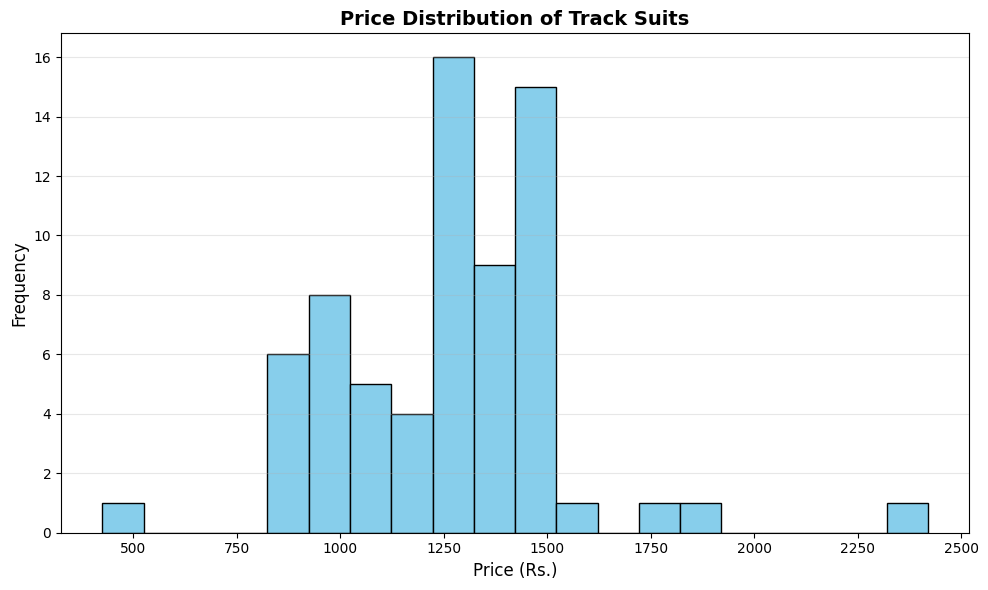

✓ Chart 1 saved: chart1_histogram.png


In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(df['Current_Price'], bins=20, color='skyblue', edgecolor='black')
plt.xlabel('Price (Rs.)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Price Distribution of Track Suits', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/chart1_histogram.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Chart 1 saved: chart1_histogram.png")


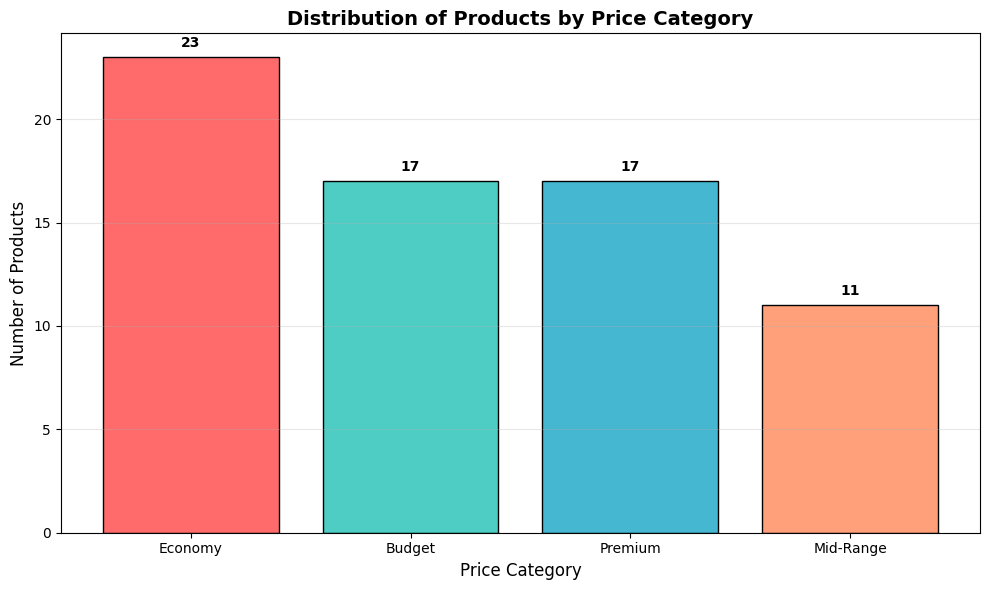

✓ Chart 2 saved: chart2_bar_chart.png


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
plt.figure(figsize=(10, 6))
price_counts = df['Price_Category'].value_counts()
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']
plt.bar(price_counts.index, price_counts.values, color=colors, edgecolor='black')
plt.xlabel('Price Category', fontsize=12)
plt.ylabel('Number of Products', fontsize=12)
plt.title('Distribution of Products by Price Category', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
for i, v in enumerate(price_counts.values):
    plt.text(i, v + 0.5, str(v), ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/chart2_bar_chart.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Chart 2 saved: chart2_bar_chart.png")

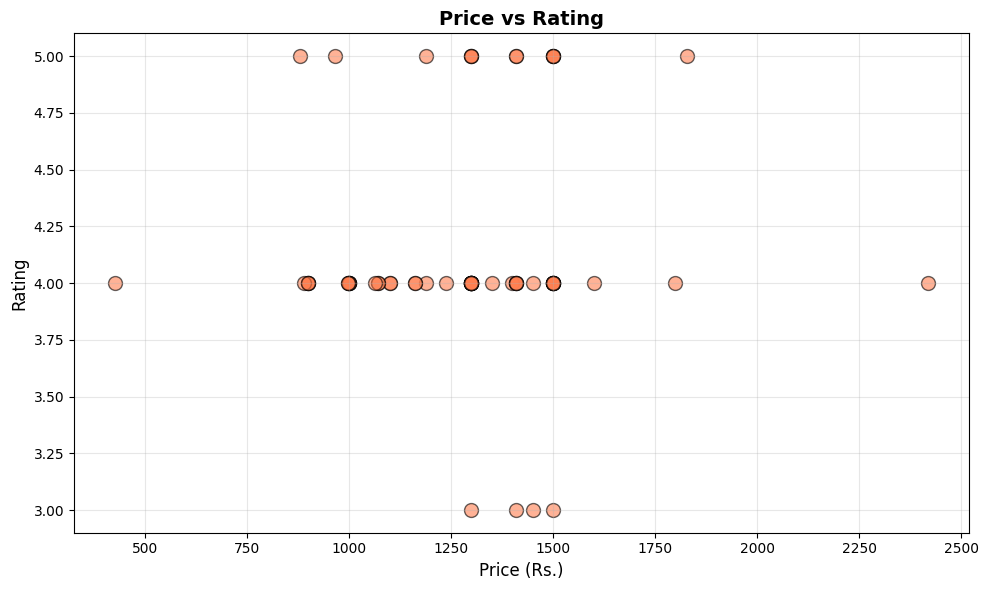

✓ Chart 3 saved: chart3_scatter_plot.png


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.figure(figsize=(10, 6))
plt.scatter(df['Current_Price'], df['Rating'], alpha=0.6, s=100, c='coral', edgecolors='black')
plt.xlabel('Price (Rs.)', fontsize=12)
plt.ylabel('Rating', fontsize=12)
plt.title('Price vs Rating', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/chart3_scatter_plot.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Chart 3 saved: chart3_scatter_plot.png")

/tmp/ipython-input-1877923888.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(data_to_plot, labels=rating_categories, patch_artist=True)


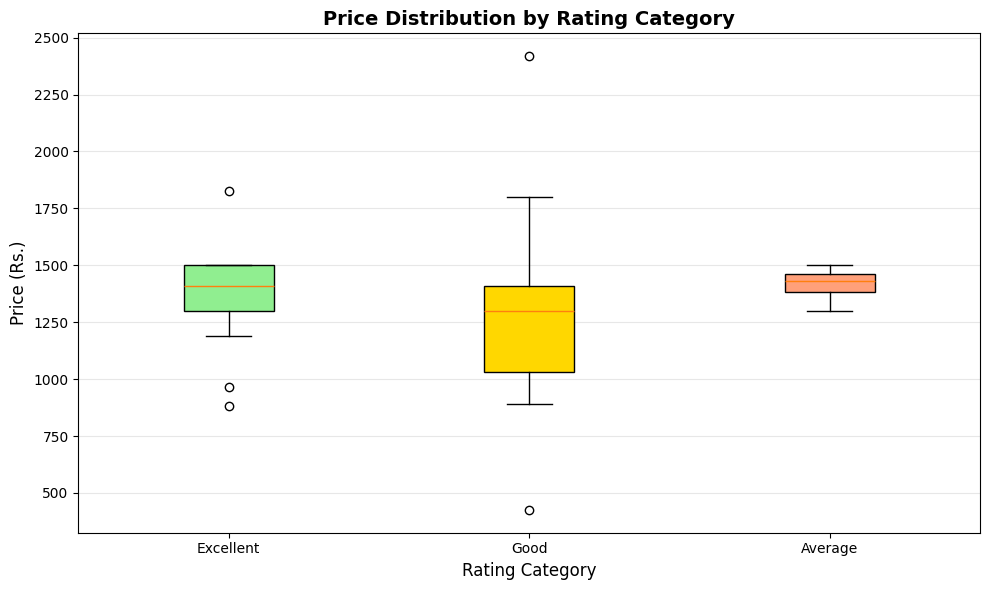

✓ Chart 4 saved: chart4_box_plot.png


In [ ]:

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.figure(figsize=(10, 6))
rating_categories = ['Excellent', 'Good', 'Average']
data_to_plot = [df[df['Rating_Category'] == cat]['Current_Price'].values
                for cat in rating_categories]
bp = plt.boxplot(data_to_plot, labels=rating_categories, patch_artist=True)
for patch, color in zip(bp['boxes'], ['#90EE90', '#FFD700', '#FFA07A']):
    patch.set_facecolor(color)
plt.xlabel('Rating Category', fontsize=12)
plt.ylabel('Price (Rs.)', fontsize=12)
plt.title('Price Distribution by Rating Category', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/chart4_box_plot.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Chart 4 saved: chart4_box_plot.png")

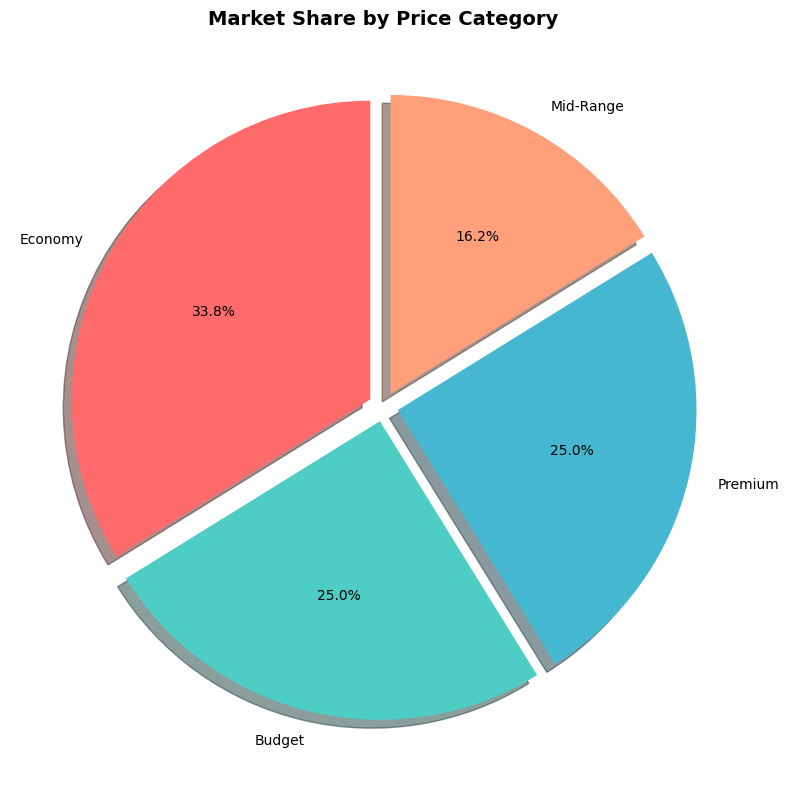

✓ Chart 5 saved: chart5_pie_chart.png


In [ ]:
plt.figure(figsize=(10, 8))
price_counts = df['Price_Category'].value_counts()
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']
explode = [0.05] * len(price_counts)
plt.pie(price_counts.values, labels=price_counts.index, autopct='%1.1f%%',
        startangle=90, colors=colors, explode=explode, shadow=True)
plt.title('Market Share by Price Category', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/chart5_pie_chart.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Chart 5 saved: chart5_pie_chart.png")